   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
Dataset loaded successfully 
Number of samples: 150
Number of features:4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names : ['setosa' 'versicolor' 'virginica']

Training set size:120
Testing set size :30

Model trained successfully

Model evaluation
Accuracy:100.00%

Classification report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      

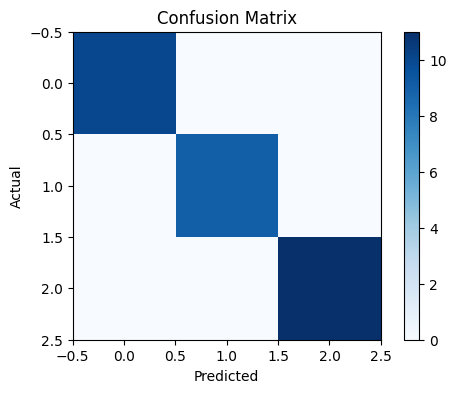


New sample prediction
Sample features:[5.1 3.5 1.4 0.2]
Predicted class:setosa

Model saved successfully


In [4]:
"""
Iris Flower Classification Project

This project uses Machine Learning to classify iris flowers
into Setosa, Versicolor, and Virginica species based on
their sepal and petal measurements.

Algorithm Used:
- Logistic Regression

Libraries Used:
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
"""
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

# Loading the Iris dataset
iris=load_iris()
X=iris.data #input features
y=iris.target #output labels

df=pd.DataFrame(X,columns=iris.feature_names)
print(df.head())

print("Dataset loaded successfully ")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features:{X.shape[1]}")
print(f"Feature names: {iris.feature_names}")
print(f"Target Names : {iris.target_names}")

# Splitting the datasets into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(f"\nTraining set size:{X_train.shape[0]}")
print(f"Testing set size :{X_test.shape[0]}")

# Training the model

model=LogisticRegression(max_iter=200) #maximum iterations for training
model.fit(X_train,y_train)
print("\nModel trained successfully")

# Making predictions
y_pred=model.predict(X_test)

# Evaluating model performance

accuracy=accuracy_score(y_test,y_pred)
print("\nModel evaluation")
print(f"Accuracy:{accuracy*100:.2f}%")
print("\nClassification report")
print(classification_report(y_test,y_pred,target_names=iris.target_names))


# Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualizing the confusion matrix

plt.figure(figsize=(6,4))
plt.imshow(cm,cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# Predicting new sample
new_sample=np.array([[5.1,3.5,1.4,0.2]])
prediction=model.predict(new_sample)
print("\nNew sample prediction")
print(f"Sample features:{new_sample[0]}")
print(f"Predicted class:{iris.target_names[prediction[0]]}")

# Saving the model

import joblib
joblib.dump(model,'iris_model.pkl')
print("\nModel saved successfully")